<a href="https://colab.research.google.com/github/rajnish80130/Real-state-Capstone-Project/blob/main/data_vizualization_for_analysis_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [6]:
df.shape

(3553, 18)

In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,la vida by tata housing,sector 113,3.00,14286.0,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167
1,flat,umang monsoon breeze,sector 78,0.88,4746.0,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111
2,flat,ireo the grand arch,sector 58,4.85,16934.0,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49
3,flat,m3m woodshire,sector 107,1.49,6311.0,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174
4,flat,ambience creacions,sector 22,6.16,20533.0,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49


In [8]:
latlong = pd.read_csv('/content/gurgaon_sector_coordinates.csv')

In [9]:
latlong

,sector,Latitude,Longitude
0,sector 1,28.518781,77.041862
1,sector 2,28.509050,77.034283
2,sector 3,28.362766,76.919326
3,sector 4,28.475006,77.010353
4,sector 5,28.480392,77.019095
...,...,...,...
110,sector 111,28.522277,77.033620
111,sector 112,28.520340,77.018861
112,sector 113,28.528665,77.025028
113,sector 114,28.531878,77.011779


In [10]:
df['sector'] = df['sector'].str.replace('sector 10a','sector 10')
df['sector'] = df['sector'].str.replace('sector 70a','sector 70')
df['sector'] = df['sector'].str.replace('sector 36a','sector 36')
df['sector'] = df['sector'].str.replace('sector 99a','sector 99')
df['sector'] = df['sector'].str.replace('sector 82a','sector 82')
df['sector'] = df['sector'].str.replace('sector 63a','sector 63')
df['sector'] = df['sector'].str.replace('sector 3 phase 2','sector 3')
df['sector'] = df['sector'].str.replace('sector 88a','sector 88')
df['sector'] = df['sector'].str.replace('sector 37c','sector 37')
df['sector'] = df['sector'].str.replace('sector 37d','sector 37')
df['sector'] = df['sector'].str.replace('sector 88b','sector 88')
df['sector'] = df['sector'].str.replace('sector 17b','sector 17')
df['sector'] = df['sector'].str.replace('sector 17a','sector 17')
df['sector'] = df['sector'].str.replace('sector 67a','sector 67')
df['sector'] = df['sector'].str.replace('sector 9a','sector 9')
df['sector'] = df['sector'].str.replace('sohna road road','sohna road')
df['sector'] = df['sector'].str.replace('sector 3 phase 3 extension','sector 3')

In [11]:
# New locations with latitudes and longitudes
new_locations = pd.DataFrame({
    "sector": ["sohna road", "manesar", "gwal pahari", "dwarka expressway"],
    "Latitude": [28.3041, 28.3544, 28.4268, 28.5227],
    "Longitude": [77.0646, 76.9254, 77.1365, 76.9878]
})

# Append new rows
latlong = pd.concat([latlong, new_locations], ignore_index=True)
latlong.tail()  # Show the last few rows to confirm addition

,sector,Latitude,Longitude
114,sector 115,28.535688,77.006943
115,sohna road,28.304100,77.064600
116,manesar,28.354400,76.925400
117,gwal pahari,28.426800,77.136500
118,dwarka expressway,28.522700,76.987800


In [12]:
latlong.rename(columns={'Latitude':'latitude','Longitude':'longitude'},inplace=True)

In [13]:
new_df = df.merge(latlong, on='sector')

In [14]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score', 'latitude',
       'longitude'],
      dtype='object')

In [15]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,flat,la vida by tata housing,sector 113,3.00,14286.0,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167,28.528665,77.025028
1,flat,umang monsoon breeze,sector 78,0.88,4746.0,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111,28.372528,76.970296
2,flat,ireo the grand arch,sector 58,4.85,16934.0,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49,28.416001,77.108556
3,flat,m3m woodshire,sector 107,1.49,6311.0,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174,28.506941,76.975214
4,flat,ambience creacions,sector 22,6.16,20533.0,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49,28.506318,77.065518


In [16]:
new_df.shape

(3553, 20)

In [17]:
group_df = new_df.groupby('sector').agg({
    'price': 'mean',
    'price_per_sqft': 'mean',
    'built_up_area': 'mean',
    'latitude': 'first',
    'longitude': 'first'
})

In [18]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
dwarka expressway,1.372500,8988.375000,1606.000000,28.522700,76.987800
gwal pahari,3.192222,9585.777778,3056.166667,28.426800,77.136500
manesar,0.962258,4608.064516,2027.367742,28.354400,76.925400
sector 1,1.860000,8249.833333,2327.833333,28.518781,77.041862
sector 10,2.092857,11866.571429,1908.857143,28.444581,77.006023
...,...,...,...,...,...
sector 92,0.934000,5928.290000,1571.341800,28.408905,76.915523
sector 93,0.848889,8009.888889,1017.000000,28.415605,76.931638
sector 95,0.480545,5602.509091,995.981818,28.414944,76.911489


In [19]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [65]:
new_df.to_csv('data_viz1.csv',index=False)

In [20]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [21]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,3.00,14285.0,2100.0,Super Built up area 2691(250 sq.m.)Built Up ar...,3,3,3+,servant room,"Sector 113 Gurgaon , Gurgaon, Haryana",3.0,East,1 to 5 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...",La vida by tata housing is one of the most pop...,"['1 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Centrally Air Conditioned', 'Water purifier'...",NaN
1,3 BHK Flat in Sector 78 Gurgaon,flat,umang monsoon breeze,0.88,4746.0,1854.0,Super Built up area 1854(172.24 sq.m.)Built Up...,3,4,3,"pooja room,servant room","654, Sector 78 Gurgaon, Gurgaon, Haryana",8.0,North-West,5 to 10 Year Old,"['Proposed Metro Station', 'Mahapal Shing', 'N...",3 bhk flat available for sell in umang monsoon...,"['1 Wardrobe', '1 Stove', '1 Chimney', '1 Modu...","['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
2,4 BHK Flat in sector 58 Gurgaon,flat,ireo the grand arch,4.85,16934.0,2864.0,Carpet area: 2864 (266.07 sq.m.),4,5,3,"pooja room,study room,servant room,others","2304, sector 58 Gurgaon, Gurgaon, Haryana",23.0,North-West,1 to 5 Year Old,"['Sector 55-56 Rapid Metro', 'Paras Trinity Ma...",Check out this 4 bhk apartment for sale in ire...,"['4 Wardrobe', '4 Fan', '1 Exhaust Fan', '6 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area5 out of 5', 'Construction5 out of..."
3,3 BHK Flat in Sector 107 Gurgaon,flat,m3m woodshire,1.49,6310.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,3+,"servant room,store room","Dwarka Express Highway, Sector 107 Gurgaon, Gu...",5.0,East,1 to 5 Year Old,"['Signum 107', 'Nora Solomon Medicenter', 'Ind...",Available 3 bhk plus servant room spacious apa...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '2 Ge...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area4.5 out of 5', 'Construction5 out ..."
4,4 BHK Flat in Sector 22 Gurgaon,flat,ambience creacions,6.16,20533.0,3000.0,Carpet area: 3000 (278.71 sq.m.),4,5,3+,"pooja room,servant room","Sector 22 Gurgaon, Gurgaon, Haryana",10.0,South-East,0 to 1 Year Old,"['Moulsari Avenue', 'Ambience Mall', 'Old Delh...",Ambience creacions is one of gurgaon's most so...,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [22]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [23]:
wordcloud_df.head()

,features,sector
0,"['Centrally Air Conditioned', 'Water purifier'...",sector 113
1,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 78
2,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 58
3,"['Centrally Air Conditioned', 'Water purifier'...",sector 107
4,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 22


In [24]:
import ast

# Flatten features with sector info
main = []
for _, row in wordcloud_df.dropna(subset=['features']).iterrows():
    sector = row['sector']
    features = ast.literal_eval(row['features'])
    for feature in features:
        main.append({'sector': sector, 'feature': feature})

# Convert to DataFrame
feature_text = pd.DataFrame(main)
feature_text.head()

,sector,feature
0,sector 113,Centrally Air Conditioned
1,sector 113,Water purifier
2,sector 113,Security / Fire Alarm
3,sector 113,Feng Shui / Vaastu Compliant
4,sector 113,Private Garden / Terrace


In [25]:
feature_text.shape

(42212, 2)

In [81]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [30]:
fig = px.sunburst(
    df1,
    path=['property_type', 'bedRoom'],  # hierarchy
    values='price_per_sqft',
    title="🏡 Sunburst Chart: Price/Sqft by Property Type & Bedroom Count",
    color='price_per_sqft',
    color_continuous_scale='Viridis'
)

fig.show()

In [26]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [32]:
fig = px.pie(df, names='bedRoom', title='BHK Pie Chart')

# Show the plot
fig.show()

In [33]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

<ipython-input-34-dc32b660127e>:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-34-dc32b660127e>:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

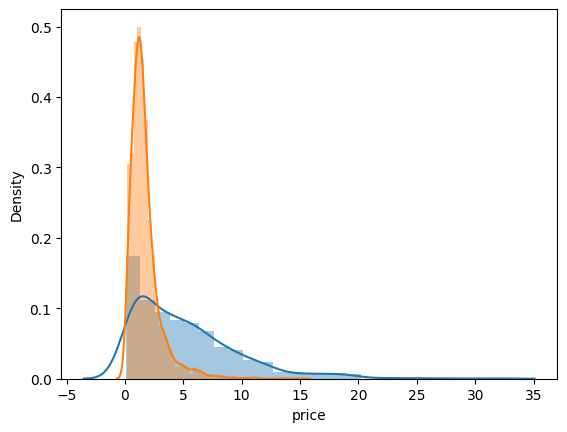

In [34]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])